In [23]:
import numpy as np
from datascience import *

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [16]:
united = Table().read_table('data/united.csv')



np.int64(292)

In [17]:
start = np.random.choice(np.arange(1000))
random_samples = united.take(np.arange(start, start + 100))

In [15]:
random_samples

Date,Flight Number,Destination,Delay
6/4/15,1942,SAN,97
6/4/15,1946,BOS,12
6/4/15,1947,PHL,29
6/4/15,1950,CLE,23
6/4/15,1957,LAX,-1
6/4/15,1958,IAH,5
6/4/15,1960,LAX,17
6/4/15,1964,SEA,0
6/4/15,1975,FLL,22
6/4/15,1983,BOS,-6


In [19]:
random_sample2 = united.sample(k = 5, with_replacement=False)
random_sample2

Date,Flight Number,Destination,Delay
6/29/15,242,BOS,9
8/15/15,540,DEN,-1
7/2/15,1593,EWR,1
8/31/15,1662,RDU,-4
6/21/15,361,LIH,114


## Distributions

In [20]:
die = Table().with_column('Face', np.arange(1, 7))
die

Face
1
2
3
4
5
6


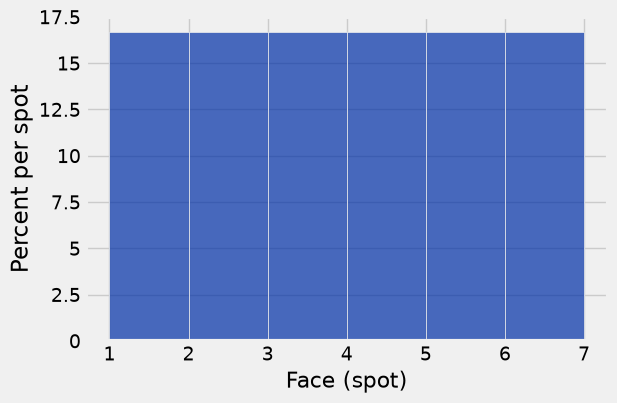

In [25]:
die.hist(bins = make_array(1, 2, 3, 4, 5, 6, 7), unit='spot')

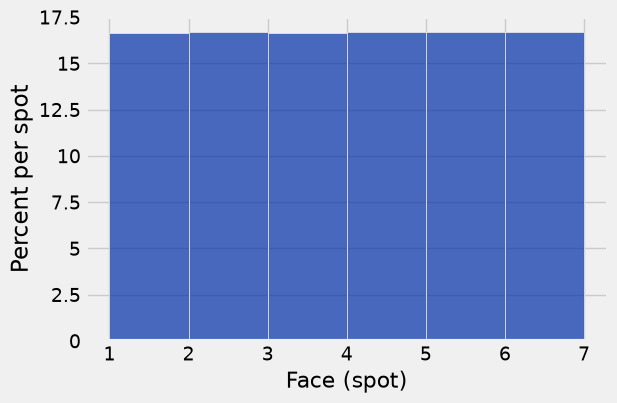

In [45]:
die.sample(10000000).hist(bins = make_array(1, 2, 3, 4, 5, 6, 7), unit='spot')

# Distribution of selay on United flights

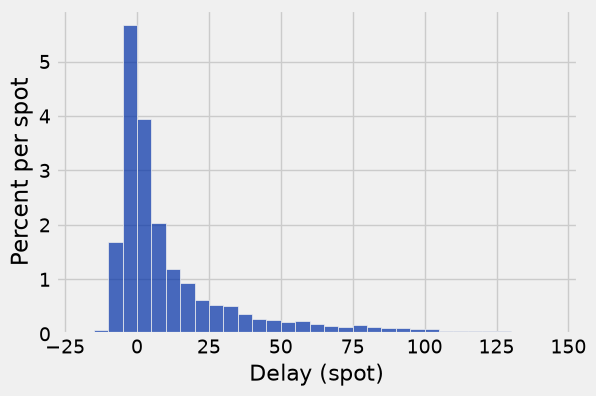

In [75]:
united_bins = np.arange(-20, 150, 5)
united.hist('Delay', bins = united_bins, unit='spot')

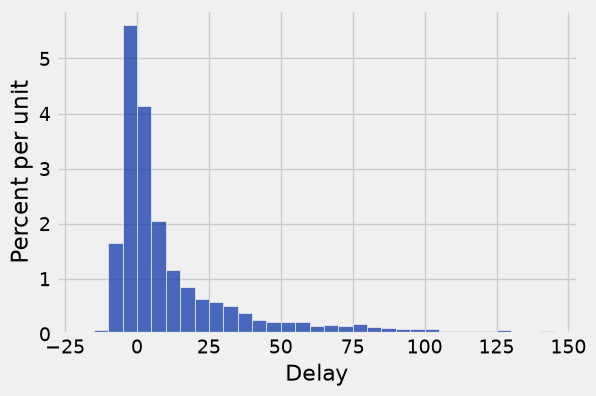

In [76]:
# Sample a few
united.sample(10000).hist('Delay', bins=united_bins)

In [104]:
np.median(united.column("Delay")), np.mean(united.column("Delay")), np.max(united.column("Delay")), np.min(united.column("Delay"))

(np.float64(2.0), np.float64(16.658155515370705), np.int64(580), np.int64(-16))

In [106]:
observed_sample_median(100)

np.float64(2.0)

In [140]:
def observed_sample_median(sample_size):
    return np.median(united.sample(sample_size).column('Delay'))

def run_sim(simulation_count, sample_size):
    observed_sample_medians = np.zeros(simulation_count)
    
    for i in np.arange(simulation_count):
        observed_sample_medians[i] = observed_sample_median(sample_size)

    return observed_sample_medians

In [ ]:
results = run_sim(100, 1000)
Table().with_columns("Sample Medians", results).hist()